In [1]:
# make sure python_course kernel is selected, restart if necessary

#importing libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Cleanup the dataset
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\stuco\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# filter for DA and US
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

In [3]:

df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

df_DA_US_exploded = df_DA_US.explode('job_skills')

df_DA_US_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [4]:
job_count = len(df_DA_US)
job_count

4350

In [ ]:
df_DA_skills = df_DA_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'}) # renaming these so its easier to follow

DA_job_count = len(df_DA_US)

# now we'll create a new column to calculate percentages of job postings

df_DA_skills['skill_percent'] = df_DA_skills['skill_count'] / DA_job_count * 100

# df_DA_skills should show SQL at 57.65%

skill_percent = 5

# let's make a new dataframe that filters the df we already made further down to show skill_percents > 5% - like temporary tables

df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percent'] > skill_percent]

df_DA_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


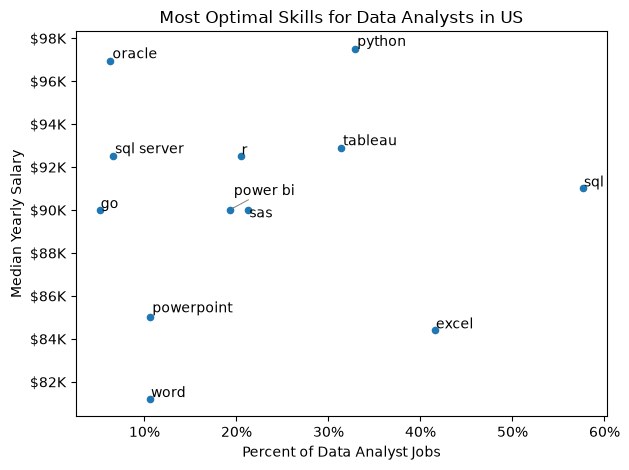

In [16]:
# we're going to use adjusttext to point arrows at datapoints to make it more readable
# we need to import this but it needs to be installed first

from adjustText import adjust_text

df_DA_skills_high_demand.plot(kind='scatter', x='skill_percent' , y='median_salary')
plt.xlabel("Percent of Data Analyst Jobs")
plt.ylabel("Median Yearly Salary")
plt.title("Most Optimal Skills for Data Analysts in US")
plt.tight_layout()


# matplotlib isn't good at making labels for datapoints, there's a workaround though ---> pyplot.text
# iterate through job skills with a for loop

texts=[] # the list here refers to the plt.text line below
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], txt))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')) # y was a float before, change the datatype
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x)}%'))
0
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='grey', lw=0.7))


plt.tight_layout()
plt.show()

In [ ]:
df['job_type_skills'].head(10)
# we're going to color code the scatterplot data points

0                                                  NaN
1    {'analyst_tools': ['power bi', 'tableau'], 'pr...
2    {'analyst_tools': ['dax'], 'cloud': ['azure'],...
3    {'cloud': ['aws'], 'libraries': ['tensorflow',...
4    {'cloud': ['oracle', 'aws'], 'other': ['ansibl...
5    {'cloud': ['gcp'], 'programming': ['python', '...
6    {'cloud': ['gcp', 'bigquery'], 'databases': ['...
7    {'cloud': ['gcp', 'azure', 'aws', 'bigquery', ...
8    {'analyst_tools': ['excel', 'powerpoint', 'pow...
9    {'analyst_tools': ['excel'], 'cloud': ['azure'...
Name: job_type_skills, dtype: str

In [ ]:
# make a copy of this df
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row) # connect string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict: # if key already exists in technolgoy_dict, add value to existing
            technology_dict[key] += value
        else:                       # if key doesn't exist, add key and value to existing
            technology_dict[key] = value 

# remove duplicates by converting values to set them back to list
for key, value in technology_dict.items():
    technology_dict[key] = list[set[value]]

technology_dict
